In [1]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input,Dense,Conv2D,MaxPooling2D,Flatten
from tensorflow.keras.datasets import cifar10
import numpy as np
import matplotlib.pyplot as plt

In [2]:
(X_train,y_train),(X_test,y_test) = cifar10.load_data()

- image의 특성 확인
> - **X_train** 또는 **X_test**의 **shape**: **(데이터의 수, 가로픽셀, 세로픽셀, 채널)**

In [3]:
print(X_train.shape, X_test.shape)

(50000, 32, 32, 3) (10000, 32, 32, 3)


- data label 확인
> - **y_train**에 **np.unique**를 활용하여, **y_train**이 포함한 값들의 종류를 확인할 수 있음

In [4]:
print(np.unique(y_train))
# 데이터 종류의 수를 확인하고자 하는 경우, len 사용 = class의 수
print(len(np.unique(y_train)))

[0 1 2 3 4 5 6 7 8 9]
10


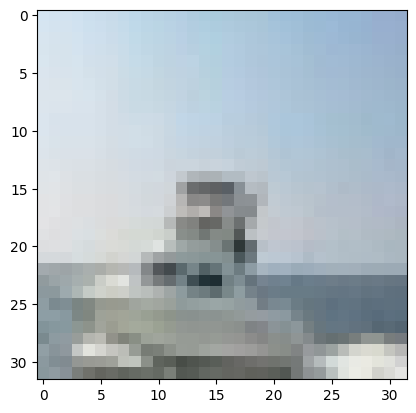

In [5]:
plt.imshow(X_train[100])

In [6]:
X_train = X_train/255
X_test = X_test/255

In [7]:
cnn_model = Sequential([
    Input(shape=(32,32,3)),
    # -- 특징 추출부
    Conv2D(filters=64,kernel_size=(3,3),strides=(1,1),activation='relu'),
    MaxPooling2D(pool_size=(2,2),strides=(2,2)),
    Conv2D(filters=32,kernel_size=(3,3),strides=(1,1),activation='relu'),
    MaxPooling2D(pool_size=(2,2),strides=(2,2)),
    # 이미지를 1d로 변경
    Flatten(),
    # -- 분류부
    Dense(units=512,activation='relu'),
    # class의 수가 10이므로 output layer node는 10으로 지정함
    Dense(units=10,activation='softmax')
])

In [8]:
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 615,722 (2.35 MB)

 Trainable params: 615,722 (2.35 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
cnn_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['acc'])

In [10]:
train_result = cnn_model.fit(X_train,y_train,validation_split=0.3,epochs=15,batch_size=1024)

Epoch 1/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 172ms/step - acc: 0.2381 - loss: 2.1077 - val_acc: 0.3923 - val_loss: 1.7065
Epoch 2/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - acc: 0.4200 - loss: 1.6240 - val_acc: 0.4581 - val_loss: 1.5175
Epoch 3/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - acc: 0.4743 - loss: 1.4704 - val_acc: 0.5033 - val_loss: 1.4026
Epoch 4/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - acc: 0.5220 - loss: 1.3453 - val_acc: 0.5291 - val_loss: 1.3569
Epoch 5/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - acc: 0.5505 - loss: 1.2840 - val_acc: 0.5649 - val_loss: 1.2536
Epoch 6/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - acc: 0.5757 - loss: 1.2185 - val_acc: 0.5702 - val_loss: 1.2270
Epoch 7/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - acc: 0.5956 - loss: 1.1545 - val_acc: 0.5792 - val_loss: 1.2136
Epoch 8/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - acc: 0.6027 - loss: 1.1343 - val_acc: 0.5920 - val_loss: 1.1721
Epoch 9/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - acc: 0.62

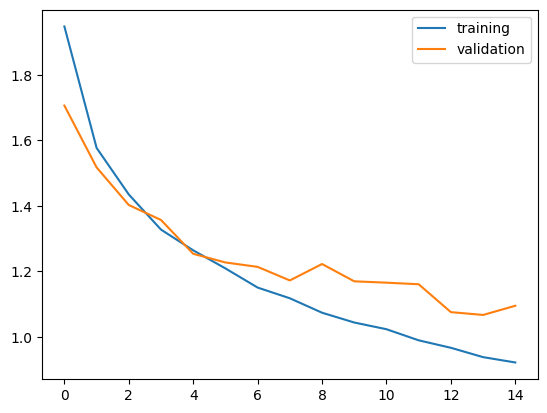

In [11]:
plt.plot(train_result.history['loss'],label='training')
plt.plot(train_result.history['val_loss'],label='validation')
plt.legend()

In [12]:
cnn_model.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.6245 - loss: 1.0817


[1.0851643085479736, 0.6225000023841858]

- **predict**를 통해 예측 결과 확인하기
> - **predict(X)** 의 결과는 입력된 **X**의 각 image에 대해 **각 class에 속할 확률을 반환**함

In [15]:
proba = cnn_model.predict(X_test)
# X_test는 10000개의 이미지로 구성되어 있으며
# predict(X_test)는 10000개의 이미지에 대해,
# 각 class에 속할 확률을 의미함
print(proba[0])      # X_test[0] 이미지가 각 class에 속할 확률
print(proba.shape)   # proba는 10000개의 이미지에 대해 각 이미지가 각 class에 속할 확률 포함하고 있음

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[3.9424393e-03 1.8228221e-04 1.8845068e-01 5.8889109e-01 2.1629611e-02
 6.4023376e-02 1.0059722e-01 1.3132419e-03 3.0685907e-02 2.8430304e-04]
(10000, 10)


- 만약 **predict**의 결과를 통해 **class label**을 확인하고자 한다면, 가장 큰 확률 갖는 열의 **index**를 추출함
- **np.argmax(ndarray,axis)** 는 가장 큰 값을 갖는 요소의 **index**를 반환
> - **axis=0**: 각 **열에 대해** 가장 큰 값을 갖는 **행의 index** 반환
> - **axis=1**: 각 **행에 대해** 가장 큰 값을 갖는 **열의 index** 반환

In [19]:
pred = np.argmax(proba,axis=1)
# X_test 각 이미지에 대해 model 예측한 class label
print(pred)
print(pred.shape)

[3 8 1 ... 5 4 7]
(10000,)


- model의 예측결과인 **pred**와 실제 label인 **y_test**를 비교하여, 잘못 분류된 이미지를 확인
- **np.argwhere(조건식)**: 조건식이 **참(True)** 인 **ndarray의 index**를 반환
> - **pred**와 **y_test**가 서로 다른 **index**를 추출함 -> 잘 못 분류된 데이터의 index
> - 해당 index의 image를 확인하고, 예측값과 실제값을 비교함

In [25]:
# y_test를 pred와 동일한 shape으로 변경한 후, np.argwhere를 적용함
# y_test.reshape(pred.shape): y_test를 pred와 동일한 shape으로 변경한다는 의미
wrong_ind = np.argwhere(pred != y_test.reshape(pred.shape))
# 잘못 분류된 이미지의 index
print(wrong_ind)

[[   2]
 [   4]
 [   8]
 ...
 [9995]
 [9996]
 [9998]]


4 [1]


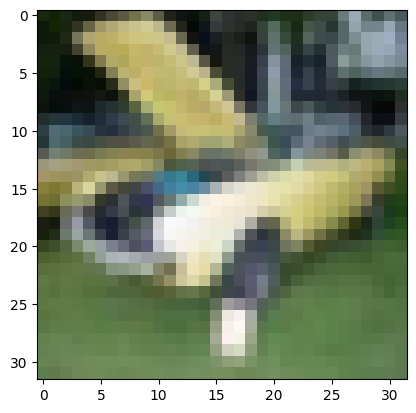

In [31]:
plt.imshow(X_test[9998])
print(pred[9998],y_test[9998])